<img src="../Decorative-Elements/Section-04/ADL-S04-Image-01.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-08.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/02-IAS15-Integrator.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-04/ADL-S04-Image-02.png">
<img src="../Decorative-Elements/Section-04/ADL-S04-Image-03.png">

In [1]:
# In REBOUND, an integrator is the numerical algorithm that advances the positions and 
# velocities of particles in time by solving the equations of motion. It determines how 
# the simulation computes the evolution of the system step by step.

# REBOUND Integrators
# whfast    : Fast, symplectic integrator, ideal for long-term planetary system simulations.
# ias15     : High-accuracy, adaptive timestep integrator, good for chaotic orbits and close encounters.
# leapfrog  : Simple symplectic integrator, conserves energy well, suitable for general N-body problems.
# janus     : Symplectic integrator for hierarchical systems with switching timestep, useful for mixed-mass systems.
# mercurius: Hybrid integrator combining symplectic and ias15 for close encounters and long-term evolution.
# sei       : Symplectic Epicyclic Integrator, optimized for disk dynamics and ring systems.

<img src="../Decorative-Elements/Section-04/ADL-S04-Image-04-a.png">

In [2]:
# WHFast Integrator - Important Use Case
# - Best for long-term simulations of planetary systems with well-separated orbits.
# - Symplectic: conserves energy over long timescales, ideal for studying orbital stability.
# - Efficient for multi-planet systems like the Solar System where close encounters are rare.

In [3]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from mpl_toolkits.mplot3d import Axes3D

In [4]:
# Function 1: Initialize Simulation
def init_simulation(semi_major_axis=1.0, eccentricity=0.5, inclination_deg=20):

    # Initializes a simple Sun + planet system.
    
    # Parameters:
    #     semi_major_axis (float): Planet's semi-major axis in AU.
    #     eccentricity (float): Planet's orbital eccentricity.
    #     inclination_deg (float): Orbital inclination in degrees.
    
    # Returns:
    #     sim (rebound.Simulation): Initialized REBOUND simulation.

    sim = rebound.Simulation()
    sim.units = ('AU', 'yr', 'Msun')
    
    # Add Sun
    sim.add(m=1.0)
    
    # Add planet
    sim.add(m=3e-6, a=semi_major_axis, e=eccentricity, inc=np.radians(inclination_deg))
    
    # Set WHFast integrator (fast, symplectic, ideal for planetary systems)
    sim.integrator = "whfast"
    sim.dt = 0.001
    
    return sim

In [5]:
# Function 2: Orbit Diagram
def plot_orbit(sim, title="Orbit Diagram"):
    # Plots 2D orbit of the planet around the Sun.
    rebound.OrbitPlot(sim, color=True, figsize=(6,6), unitlabel="AU")
    plt.title(title)
    plt.show()

In [6]:
# Function 3: Distance vs Time
def distance_vs_time(sim, duration_years=2, steps=2000, title="Distance vs Time"):
    # Computes and plots planet-Sun distance over time.
    
    # Returns:
    #     times (array): Array of time points [yr].
    #     distances (array): Distance from Sun at each time [AU].
    times = np.linspace(0, duration_years, steps)
    distances = []
    
    for t in times:
        sim.integrate(t)
        p = sim.particles[1]
        r = np.sqrt(p.x**2 + p.y**2 + p.z**2)
        distances.append(r)
    
    # Plot distance
    plt.figure(figsize=(8,4))
    plt.plot(times, distances, color='darkblue', lw=2)
    plt.xlabel("Time [yr]")
    plt.ylabel("Distance from Sun [AU]")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    return times, np.array(distances)

In [7]:
# Function 4: Orbital Period
def orbital_period(semi_major_axis, times=None, distances=None):
    # Computes orbital period using Kepler's law and optionally from simulation peaks.
    
    # Parameters:
    #     semi_major_axis (float): Semi-major axis of orbit [AU].
    #     times (array): Time array from simulation [yr].
    #     distances (array): Distance array from simulation [AU].
    
    # Returns:
    #     P_kepler (float): Orbital period from Kepler's law [yr].
    #     P_sim (float or None): Orbital period from simulation [yr], if distances provided.
    P_kepler = np.sqrt(semi_major_axis**3)
    print(f"Orbital period (Kepler's law): {P_kepler:.3f} yr")
    
    P_sim = None
    if distances is not None and times is not None:
        # Find local minima/maxima in distance to approximate period
        min_indices = (np.diff(np.sign(np.diff(distances))) > 0).nonzero()[0] + 1
        if len(min_indices) > 1:
            P_sim = np.mean(np.diff(times[min_indices]))
            print(f"Orbital period (simulation): {P_sim:.3f} yr")
    
    return P_kepler, P_sim

In [8]:
# Function 5: Planet Position at Specific Date
def update_to_date(sim, target_date, reference_date=datetime(2000,1,1)):
    # Integrates simulation to a specific calendar date and returns planet position.
    
    # Parameters:
    #     target_date (datetime): Desired date.
    #     reference_date (datetime): Reference start date of simulation.
    
    # Returns:
    #     tuple: (x, y, z) position of planet in AU.
    delta_days = (target_date - reference_date).days + (target_date - reference_date).seconds/86400
    t_years = delta_days / 365.25
    sim.integrate(t_years)
    
    p = sim.particles[1]
    return (p.x, p.y, p.z)

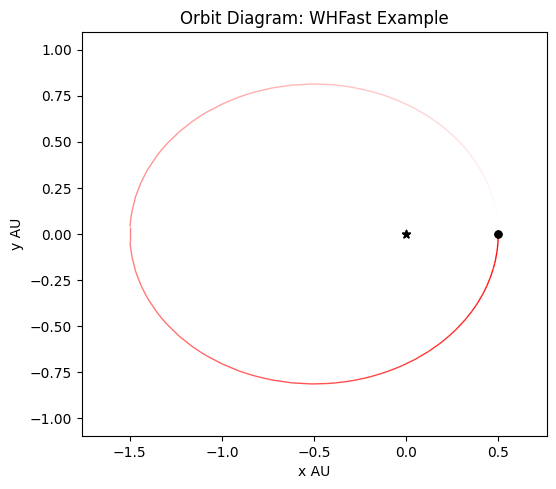

In [9]:
# Main Program - Outputs
# 1. Initialize simulation
sim = init_simulation(semi_major_axis=1.0, eccentricity=0.5, inclination_deg=20)

# 2. Orbit diagram
plot_orbit(sim, title="Orbit Diagram: WHFast Example")

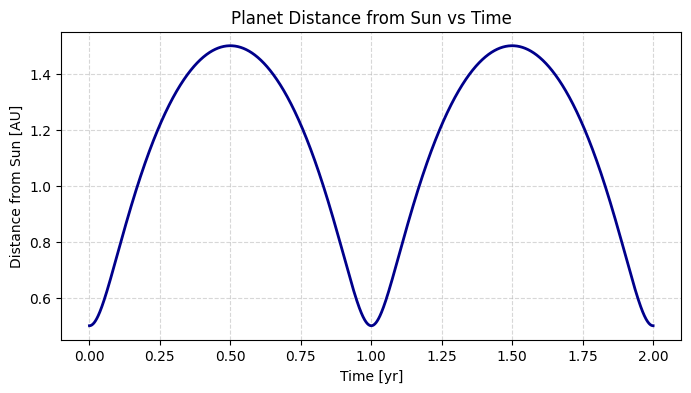

In [10]:
# 3. Distance vs Time
times, distances = distance_vs_time(sim, duration_years=2, title="Planet Distance from Sun vs Time")

In [11]:
# 4. Orbital period
orbital_period(1.0, times, distances);

Orbital period (Kepler's law): 1.000 yr


In [12]:
# 5. Planet position today
today = datetime.now()
pos = update_to_date(sim, today)
print(f"Current planet position (AU): x={pos[0]:.3f}, y={pos[1]:.3f}, z={pos[2]:.3f}")

Current planet position (AU): x=-0.483, y=0.814, z=0.296


In [13]:
# Function 1: Initialize Solar System for Kepler Visualization
def init_solar_system_kepler():
    # Initializes Sun + 8 planets with semi-major axis, eccentricity, and inclination
    # for Kepler's law visualization.
    
    # Returns:
    #     sim (rebound.Simulation): Simulation object.
    #     planet_names (list): List of planet names.
    sim = rebound.Simulation()
    sim.units = ('AU', 'yr', 'Msun')
    
    # Add Sun
    sim.add(m=1.0)
    
    # Planet data: name, mass [Msun], semi-major axis [AU], eccentricity, inclination [deg]
    planets = [
        ("Mercury", 1.66e-7, 0.39, 0.205, 7.0),
        ("Venus",   2.45e-6, 0.72, 0.0067, 3.39),
        ("Earth",   3.00e-6, 1.00, 0.0167, 0.0),
        ("Mars",    3.23e-7, 1.52, 0.093, 1.85),
        ("Jupiter", 9.54e-4, 5.20, 0.048, 1.30),
        ("Saturn",  2.86e-4, 9.58, 0.056, 2.49),
        ("Uranus",  4.37e-5,19.2, 0.047, 0.77),
        ("Neptune", 5.15e-5,30.1, 0.009, 1.77)
    ]
    
    planet_names = []
    for name, m, a, e, inc in planets:
        sim.add(m=m, a=a, e=e, inc=np.radians(inc))
        planet_names.append(name)
    
    # WHFast integrator: symplectic, fast for multiple planets
    sim.integrator = "whfast"
    sim.dt = 0.01
    
    return sim, planet_names

In [14]:
# Function 2: Distance vs Time Grid
def distance_vs_time_kepler_with_time(sim, planet_indices, planet_names, duration_years_dict, steps=1000):
    # Plots distance from Sun vs time for multiple planets in a grid layout.
    # Shows sampled points along with continuous curve.
    
    # Parameters:
    #     sim (rebound.Simulation): Simulation object.
    #     planet_indices (list): Indices of planets in simulation.
    #     planet_names (list): Names of planets corresponding to indices.
    #     duration_years_dict (dict): Duration for each planet [yr].
    #     steps (int): Number of time steps for integration.
    n_planets = len(planet_indices)
    n_cols = 4
    n_rows = (n_planets + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20,5))
    axes = axes.flatten()
    
    for i, idx in enumerate(planet_indices):
        duration = duration_years_dict.get(planet_names[i], 2)
        times = np.linspace(0, duration, steps)
        distances = []
        
        for t in times:
            sim.integrate(t)
            p = sim.particles[idx]
            r = np.sqrt(p.x**2 + p.y**2 + p.z**2)
            distances.append(r)
        
        distances = np.array(distances)
        
        # Plot continuous distance curve
        axes[i].plot(times, distances, lw=2, color='darkblue')
        # Overlay sampled points for time reference
        axes[i].scatter(times[::100], distances[::100], color='red', s=10, label="Sample points")
        
        axes[i].set_title(f"{planet_names[i]}")
        axes[i].set_xlabel("Time [yr]")
        axes[i].set_ylabel("Distance [AU]")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend()
    
    # Hide unused axes if any
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle("Kepler's Law: Distance vs Time for All Planets", fontsize=18)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

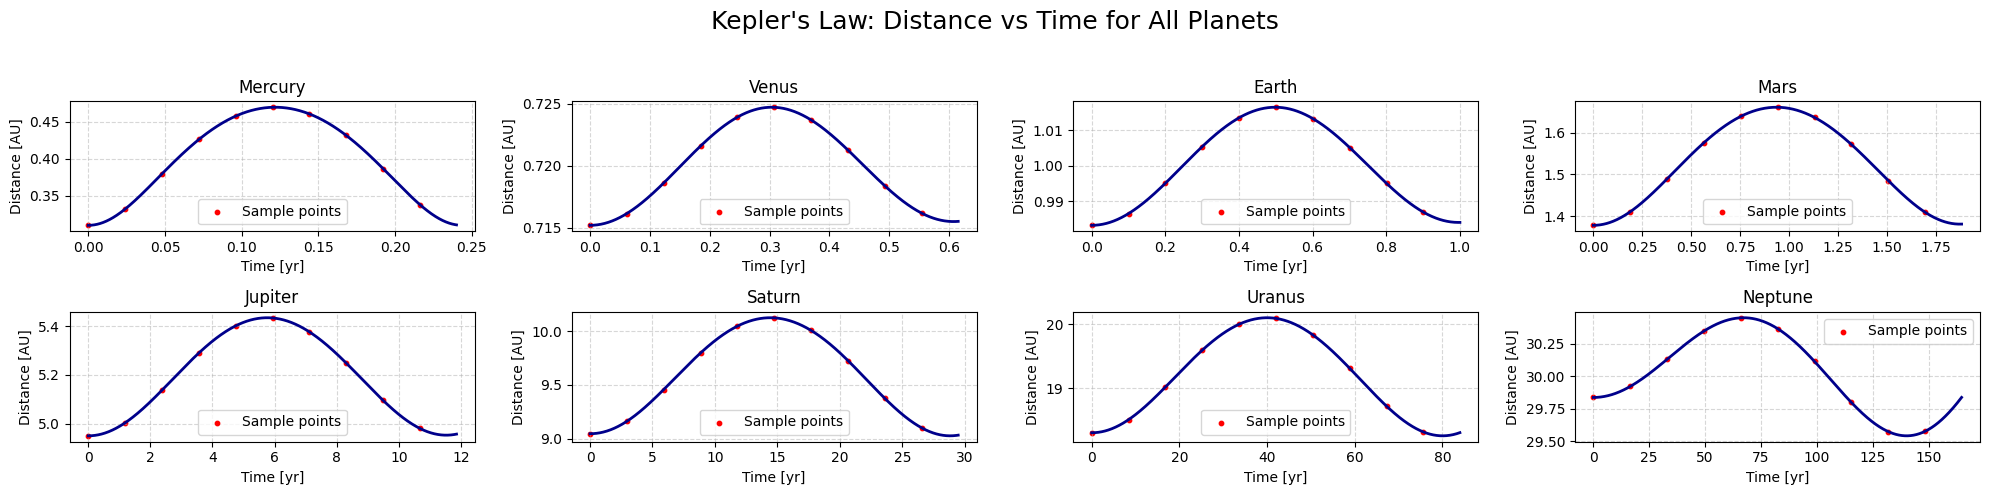

In [15]:
# Main Program - Outputs
# Initialize Solar System simulation
sim, planet_names = init_solar_system_kepler()
planet_indices = list(range(1, 9))  # Planets are particles 1-8

# Approximate orbital periods used as duration for plotting
duration_years_dict = {
    "Mercury": 0.24,
    "Venus": 0.615,
    "Earth": 1.0,
    "Mars": 1.88,
    "Jupiter": 11.86,
    "Saturn": 29.46,
    "Uranus": 84.01,
    "Neptune": 164.8
}

# Generate distance vs time plots
distance_vs_time_kepler_with_time(sim, planet_indices, planet_names, duration_years_dict, steps=1000)

In [16]:
# Function 1: Initialize Solar System
def init_solar_system_kepler():
    # Initializes Sun + 8 planets for Kepler's law demonstration.
    
    # Returns:
    #     sim (rebound.Simulation): Initialized simulation.
    #     planet_names (list): List of planet names.
    #     planets (list): Full planet data [(name, mass, a, e, inc), ...].
    sim = rebound.Simulation()
    sim.units = ('AU', 'yr', 'Msun')
    
    # Sun
    sim.add(m=1.0)
    
    # Planets: name, mass, semi-major axis [AU], eccentricity, inclination [deg]
    planets = [
        ("Mercury", 1.66e-7, 0.39, 0.205, 7.0),
        ("Venus",   2.45e-6, 0.72, 0.0067, 3.39),
        ("Earth",   3.00e-6, 1.00, 0.0167, 0.0),
        ("Mars",    3.23e-7, 1.52, 0.093, 1.85),
        ("Jupiter", 9.54e-4, 5.20, 0.048, 1.30),
        ("Saturn",  2.86e-4, 9.58, 0.056, 2.49),
        ("Uranus",  4.37e-5,19.2, 0.047, 0.77),
        ("Neptune", 5.15e-5,30.1, 0.009, 1.77)
    ]
    
    planet_names = []
    for name, m, a, e, inc in planets:
        sim.add(m=m, a=a, e=e, inc=np.radians(inc))
        planet_names.append(name)
    
    # WHFast integrator for long-term planetary systems
    sim.integrator = "whfast"
    sim.dt = 0.01
    
    return sim, planet_names, planets

In [17]:
# Function 2: Compute Kepler's Periods and Distances
def kepler_periods_and_distances(sim, planet_indices, planets, steps=1000):
    # Prints Kepler's orbital periods and sample distance-time data for each planet.
    # Also returns distances and times arrays for optional plotting.
    planet_data = {}
    
    for i, idx in enumerate(planet_indices):
        name, m, a, e, inc = planets[i]
        # Kepler's law: P^2 = a^3
        P_kepler = np.sqrt(a**3)
        print(f"{name}: Semi-major axis = {a} AU, Eccentricity = {e}")
        print(f"   Kepler's orbital period = {P_kepler:.3f} years")
        
        # Distance vs time arrays
        times = np.linspace(0, P_kepler, steps)
        distances = []
        for t in times:
            sim.integrate(t)
            p = sim.particles[idx]
            r = np.sqrt(p.x**2 + p.y**2 + p.z**2)
            distances.append(r)
        distances = np.array(distances)
        
        # Sample values
        print("   Sample distance-time values (every ~100 steps):")
        for j in range(0, steps, steps//10):
            print(f"      Time = {times[j]:.3f} yr, Distance = {distances[j]:.3f} AU")
        print("---------------------------------------------------")
        
        # Store for optional plotting
        planet_data[name] = (times, distances)
    
    return planet_data

In [18]:
# Function 3: 3D Orbit Visualization (Scaled)
def plot_3d_orbits_scaled(sim, planet_indices, planet_names, scale_factor=1.2):
    # Plots 3D orbits of selected planets in the solar system with scaled axes for visibility.
    
    # Parameters:
    #     sim (rebound.Simulation): The solar system simulation object.
    #     planet_indices (list): Indices of planets to plot.
    #     planet_names (list): Names of the planets.
    #     scale_factor (float): Factor to scale the axes by, default 1.2.
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Determine maximum orbit radius to set axes limits
    max_radius = max([sim.particles[idx].a for idx in planet_indices])
    lim = max_radius * scale_factor
    
    for idx, name in zip(planet_indices, planet_names):
        # Copy simulation for integration to avoid modifying original
        sim_copy = sim.copy()
        steps = 1000
        times = np.linspace(0, 1, steps)  # 1 year integration for demonstration
        xs, ys, zs = [], [], []
        for t in times:
            sim_copy.integrate(t)
            p = sim_copy.particles[idx]
            xs.append(p.x)
            ys.append(p.y)
            zs.append(p.z)
        ax.plot(xs, ys, zs, lw=1.5, label=name)
    
    # Scale axes equally for better visibility
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])
    
    ax.set_xlabel("X [AU]")
    ax.set_ylabel("Y [AU]")
    ax.set_zlabel("Z [AU]")
    ax.set_title("3D Orbits of Planets (Scaled)")
    ax.legend()
    plt.show()

In [19]:
# Main Program
# Initialize Solar System
sim, planet_names, planets = init_solar_system_kepler()
planet_indices = list(range(1, 9))  # Planets are particles 1-8

# Compute Kepler periods and sample distances
planet_data = kepler_periods_and_distances(sim, planet_indices, planets, steps=1000)

# Optional: Plot 3D orbits for visualization
# plot_3d_orbits(sim, planet_indices, planet_names)

Mercury: Semi-major axis = 0.39 AU, Eccentricity = 0.205
   Kepler's orbital period = 0.244 years
   Sample distance-time values (every ~100 steps):
      Time = 0.000 yr, Distance = 0.310 AU
      Time = 0.024 yr, Distance = 0.333 AU
      Time = 0.049 yr, Distance = 0.381 AU
      Time = 0.073 yr, Distance = 0.428 AU
      Time = 0.098 yr, Distance = 0.459 AU
      Time = 0.122 yr, Distance = 0.470 AU
      Time = 0.146 yr, Distance = 0.459 AU
      Time = 0.171 yr, Distance = 0.428 AU
      Time = 0.195 yr, Distance = 0.381 AU
      Time = 0.219 yr, Distance = 0.332 AU
---------------------------------------------------
Venus: Semi-major axis = 0.72 AU, Eccentricity = 0.0067
   Kepler's orbital period = 0.611 years
   Sample distance-time values (every ~100 steps):
      Time = 0.000 yr, Distance = 0.715 AU
      Time = 0.061 yr, Distance = 0.716 AU
      Time = 0.122 yr, Distance = 0.719 AU
      Time = 0.183 yr, Distance = 0.722 AU
      Time = 0.245 yr, Distance = 0.724 AU
      

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-08.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/02-IAS15-Integrator.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-04-01.gif">